<a href="https://colab.research.google.com/github/Jp98-dev/Desafio-Dio.me/blob/main/trabalho_nlp_resolucao.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Atividade Prática — NLP — UNINTER 2025
### Classificador de Fake News com corpus FakeBr
**Aluno:** João Paulo Araújo Maciel  
**RU:** 4469366

In [48]:
import os
import subprocess

# Ensure the NLP repo is cloned and we are in it
if not os.path.exists('NLP'):
    os.system('git clone --recurse-submodules https://github.com/N-CPUninter/NLP.git')

if os.path.basename(os.getcwd()) != 'NLP':
    os.chdir('NLP')

# Define submodule path and URL for direct cloning
submodule_path = 'Fake.br-Corpus'
submodule_url = 'https://github.com/roneysco/Fake.br-Corpus.git'

# Check if the submodule directory exists and is not empty
if not os.path.exists(submodule_path) or not os.listdir(submodule_path):
    print(f"Submodule '{submodule_path}' not found or empty. Attempting direct clone...")
    # Clean up any existing empty or partial directory
    if os.path.exists(submodule_path):
        os.system(f'rm -rf {submodule_path}')

    # Perform a direct clone of the submodule repository
    result = subprocess.run(['git', 'clone', submodule_url, submodule_path], capture_output=True, text=True)
    print("Direct clone output:")
    print(result.stdout)
    print(result.stderr)

    if not os.path.exists(submodule_path) or not os.listdir(submodule_path):
        print(f"Failed to properly clone '{submodule_path}'. Manual intervention might be needed.")
    else:
        print(f"Submodule '{submodule_path}' successfully cloned.")
else:
    print(f"Submodule '{submodule_path}' already exists and is not empty.")


print('Diretório atual:', os.getcwd())
print('Arquivos disponíveis (primeiro nível):', os.listdir('.'))
if os.path.exists(submodule_path):
    print(f"Arquivos disponíveis em '{submodule_path}':", os.listdir(submodule_path))


Submodule 'Fake.br-Corpus' already exists and is not empty.
Diretório atual: /content/NLP
Arquivos disponíveis (primeiro nível): ['.readme_docs', 'NLP', '.gitignore', 'trabalho_nlp.ipynb', 'README.md', '__pycache__', 'data', '.gitmodules', 'nuvens_palavras_resultado.png', 'Fake.br-Corpus', 'LICENSE', '.git', 'funcoes_auxiliares.py']
Arquivos disponíveis em 'Fake.br-Corpus': ['size_normalized_texts', 'README.md', 'preprocessed', '.git', 'full_texts']


In [49]:
import subprocess
subprocess.run(['pip', 'install', 'wordcloud', 'nltk', 'pillow', '--quiet'], check=True)
print('Dependências instaladas.')

Dependências instaladas.


In [50]:
import re
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import RSLPStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from funcoes_auxiliares import gerar_nuvem_palavras

nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('rslp', quiet=True)


RU = 4469366

print('Imports concluídos.')
print(f'RU do aluno: {RU}')

Imports concluídos.
RU do aluno: 4469366


In [51]:
CSV_PATH = os.path.join('Fake.br-Corpus', 'preprocessed', 'pre-processed.csv')

df = pd.read_csv(CSV_PATH, encoding='utf-8')
print('Colunas:', df.columns.tolist())
print('Shape:', df.shape)
print(df.head(3))
print()
print('Distribuição de rótulos:')
print(df.iloc[:, 0].value_counts())

Colunas: ['index', 'label', 'preprocessed_news']
Shape: (7200, 3)
   index label                                  preprocessed_news
0      0  fake  katia abreu diz vai colocar expulsao moldura n...
1      1  fake  ray peita bolsonaro conservador fake entrevist...
2      2  fake  reinaldo azevedo desmascarado policia federal ...

Distribuição de rótulos:
index
7183    1
7182    1
7181    1
7180    1
7179    1
       ..
4       1
3       1
2       1
1       1
0       1
Name: count, Length: 7200, dtype: int64


In [52]:
col_label = None
col_texto = None

for col in df.columns:
    valores_unicos = df[col].dropna().unique()
    # coluna com apenas 'fake', 'real' ou 'true' (case-insensitive) é o label
    # Usamos issubset para permitir flexibilidade com os rótulos presentes ('true' vs 'real')
    if set(str(v).strip().lower() for v in valores_unicos).issubset({'fake', 'real', 'true'}):
        col_label = col
    # coluna com dtype object e média de comprimento de string > 50 é o texto
    elif df[col].dtype == object and df[col].astype(str).str.len().mean() > 50:
        col_texto = col

# Fallback se não encontrou automaticamente
if col_label is None:
    # Se a detecção automática falhou, assume 'label' como a coluna de rótulo, se existir
    if 'label' in df.columns:
        col_label = 'label'
    else:
        col_label = df.columns[0] # Fallback para a primeira coluna como último recurso

if col_texto is None:
    # Se a detecção automática falhou, assume 'preprocessed_news' como a coluna de texto, se existir
    if 'preprocessed_news' in df.columns:
        col_texto = 'preprocessed_news'
    else:
        col_texto = df.columns[1] # Fallback para a segunda coluna como último recurso

print(f'Coluna de rótulo: {col_label}')
print(f'Coluna de texto:  {col_texto}')

# Padroniza nomes e garante que as colunas são do tipo string antes de aplicar métodos .str
df['label'] = df[col_label].astype(str).str.strip().str.lower()  # 'fake' ou 'real'
df['texto']  = df[col_texto].fillna('').astype(str)

# Padroniza rótulos 'true' para 'real'
df['label'] = df['label'].replace('true', 'real')

print('\nDistribuição:')
print(df['label'].value_counts())

Coluna de rótulo: label
Coluna de texto:  preprocessed_news

Distribuição:
label
fake    3600
real    3600
Name: count, dtype: int64


In [53]:
stemmer_RU = RSLPStemmer()
stopwords_RU = set(stopwords.words('portuguese'))

def preprocessar_texto(texto: str) -> str:
    """Limpeza, tokenização, remoção de stopwords e stemming (NLTK)."""
    texto = str(texto).lower()
    texto = re.sub(r'[^a-záéíóúãõâêîôûàç\s]', ' ', texto)
    texto = re.sub(r'\s+', ' ', texto).strip()
    tokens = word_tokenize(texto, language='portuguese')
    tokens = [
        stemmer_RU.stem(t)
        for t in tokens
        if t not in stopwords_RU and len(t) > 2
    ]
    return ' '.join(tokens)

print('Processando textos (pode demorar alguns minutos)...')
df['texto_processado'] = df['texto'].apply(preprocessar_texto)
print('Pré-processamento concluído.')
print(df[['label', 'texto_processado']].head(3))

Processando textos (pode demorar alguns minutos)...
Pré-processamento concluído.
  label                                   texto_processado
0  fake  kat abr diz vai coloc expulsa mold nao reclam ...
1  fake  ray peit bolsonar conserv fak entrev danil gen...
2  fake  reinald azeved desmascar polic feder ferrenh c...


In [54]:
df['n_palavras'] = df['texto_processado'].str.split().str.len()

media_fake = int(df[df['label'] == 'fake']['n_palavras'].mean())
media_real = int(df[df['label'] == 'real']['n_palavras'].mean())

print(f'Média de palavras — FAKE: {media_fake}')
print(f'Média de palavras — REAL: {media_real}')

# Trunca os textos REAL para a média de palavras dos FAKE
def truncar(texto: str, limite: int) -> str:
    palavras = texto.split()
    return ' '.join(palavras[:limite])

df['texto_normalizado'] = df.apply(
    lambda row: truncar(row['texto_processado'], media_fake)
    if row['label'] == 'real'
    else row['texto_processado'],
    axis=1
)

print('\nApós normalização:')
print(df.groupby('label')['texto_normalizado'].apply(
    lambda x: x.str.split().str.len().mean()
).rename('media_palavras'))

Média de palavras — FAKE: 104
Média de palavras — REAL: 609

Após normalização:
label
fake    104.976667
real    103.771111
Name: media_palavras, dtype: float64


In [55]:
X = df['texto_normalizado']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print(f'Treino: {X_train.shape[0]} textos')
print(f'Teste:  {X_test.shape[0]} textos')
print('Distribuição no treino:')
print(y_train.value_counts())

Treino: 5400 textos
Teste:  1800 textos
Distribuição no treino:
label
real    2700
fake    2700
Name: count, dtype: int64


In [56]:
vectorizer_RU = TfidfVectorizer(
    ngram_range=(1, 2),   # unigramas e bigramas
    max_features=50000,
    sublinear_tf=True
)

X_train_tfidf = vectorizer_RU.fit_transform(X_train)
X_test_tfidf  = vectorizer_RU.transform(X_test)

feature_names_RU = vectorizer_RU.get_feature_names_out()
print(f'Total de features (tokens) no vocabulário TF-IDF: {len(feature_names_RU)}')

Total de features (tokens) no vocabulário TF-IDF: 50000


In [57]:
modelo_RU = LogisticRegression(
    C=1.0,
    max_iter=1000,
    solver='lbfgs',
    random_state=42
)
modelo_RU.fit(X_train_tfidf, y_train)

# Avalia&#231;&#227;o
y_pred = modelo_RU.predict(X_test_tfidf)
acuracia_RU = accuracy_score(y_test, y_pred)

print(f'\n=== RESULTADO DO MODELO ===')
print(f'Acur&#221;cia: {acuracia_RU * 100:.2f}%')
print(f'RU: {RU}')
print()
print('Relat&#243;rio de classifica&#231;&#227;o:')
print(classification_report(y_test, y_pred))


=== RESULTADO DO MODELO ===
Acur&#221;cia: 90.06%
RU: 4469366

Relat&#243;rio de classifica&#231;&#227;o:
              precision    recall  f1-score   support

        fake       0.90      0.90      0.90       900
        real       0.90      0.90      0.90       900

    accuracy                           0.90      1800
   macro avg       0.90      0.90      0.90      1800
weighted avg       0.90      0.90      0.90      1800



In [58]:
import numpy as np

# &#205;ndices das amostras de treino por classe
y_train_arr = np.array(y_train)
idx_real = np.where(y_train_arr == 'real')[0]
idx_fake = np.where(y_train_arr == 'fake')[0]

# M&#233;dia TF-IDF por feature para cada classe
mean_tfidf_real = np.asarray(X_train_tfidf[idx_real].mean(axis=0)).flatten()
mean_tfidf_fake = np.asarray(X_train_tfidf[idx_fake].mean(axis=0)).flatten()

def build_word_dict(mean_tfidf, feature_names, ru, top_n=5000):
    """Constr&#243;i dicion&#225;rio {token: peso_tfidf} para nuvem de palavras."""
    # Pega os top_n tokens por peso
    top_indices = np.argsort(mean_tfidf)[::-1][:top_n]
    word_dict = {
        feature_names[i]: float(mean_tfidf[i])
        for i in top_indices
        if mean_tfidf[i] > 0
    }
    # Adiciona o RU como token vis&#237;vel na nuvem
    if word_dict:
        max_val = max(word_dict.values())
        word_dict[f'RU {ru}'] = max_val * 0.85
    return word_dict

dict_real_RU = build_word_dict(mean_tfidf_real, feature_names_RU, RU)
dict_fake_RU = build_word_dict(mean_tfidf_fake, feature_names_RU, RU)

print(f'Tokens no dicion&#225;rio REAL: {len(dict_real_RU)}')
print(f'Tokens no dicion&#225;rio FAKE: {len(dict_fake_RU)}')

Tokens no dicion&#225;rio REAL: 5001
Tokens no dicion&#225;rio FAKE: 5001


---
## QUESTÃO 01 — Nuvem de palavras dos textos VERDADEIROS (REAL)

**Enunciado:** Apresente o código referente ao modelo gerado e a nuvem de palavras usada para identificar textos VERDADEIROS.

=== QUESTÃO 01 — Textos VERDADEIROS (REAL) ===
Unigramas usados : 3217
Bigramas usados  : 1783
Trigramas usados : 0
Total de tokens  : 5001
Acurácia do modelo: 90.06%
RU: 4469366

Gerando nuvem de palavras REAL...
   * Um total de 5001 tokens foram computadas a partir do conjunto de dados.



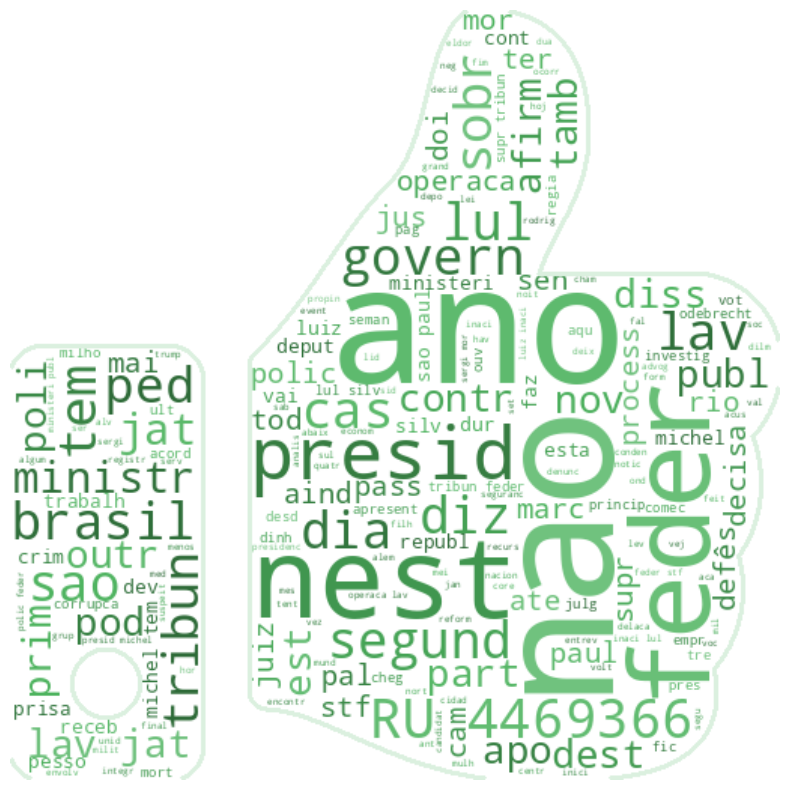

In [59]:
# Conta unigramas e bigramas no dicionário REAL
total_tokens_real_RU = len(dict_real_RU)
unigramas_real  = sum(1 for k in dict_real_RU if len(k.split()) == 1 and not k.startswith('RU'))
bigramas_real   = sum(1 for k in dict_real_RU if len(k.split()) == 2 and not k.startswith('RU'))
trigramas_real  = sum(1 for k in dict_real_RU if len(k.split()) >= 3 and not k.startswith('RU'))

print('=== QUESTÃO 01 — Textos VERDADEIROS (REAL) ===')
print(f'Unigramas usados : {unigramas_real}')
print(f'Bigramas usados  : {bigramas_real}')
print(f'Trigramas usados : {trigramas_real}')
print(f'Total de tokens  : {total_tokens_real_RU}')
print(f'Acurácia do modelo: {acuracia_RU * 100:.2f}%')
print(f'RU: {RU}')

# Gera a nuvem de palavras para REAL (polegar para cima = verde)
print('\nGerando nuvem de palavras REAL...')
# Corrigido: Passando apenas o nome do arquivo, pois a função já adiciona o caminho data/img/
nuvem_real, n_tokens_real = gerar_nuvem_palavras(
    arquivo_mascara='thumbs_up_mask.png',
    dicionario_tokens_e_frequencia=dict_real_RU
)

### Resposta — Questão 01

**Pergunta:** Quantas palavras, bigramas e trigramas foram usados dos textos rotulados como REAL para a criação de seu modelo e qual a acurácia?

**Resposta:** (Preencher com os valores impressos pela célula acima após executar.)

Exemplo de preenchimento:
- Unigramas: `<valor impresso>`
- Bigramas: `<valor impresso>`
- Trigramas: 0 (ngram_range=(1,2), trigramas não utilizados)
- Total de tokens no modelo: `<valor impresso>`
- Acurácia: `<valor impresso>`%

---
## QUESTÃO 02 — Nuvem de palavras dos textos FALSOS (FAKE)

**Enunciado:** Apresente o código referente ao modelo gerado e a nuvem de palavras usada para identificar textos FALSOS.

=== QUESTÃO 02 — Textos FALSOS (FAKE) ===
Unigramas usados : 3392
Bigramas usados  : 1608
Trigramas usados : 0
Total de tokens  : 5001
Acurácia do modelo: 90.06%
RU: 4469366

Gerando nuvem de palavras FAKE...
   * Um total de 5001 tokens foram computadas a partir do conjunto de dados.



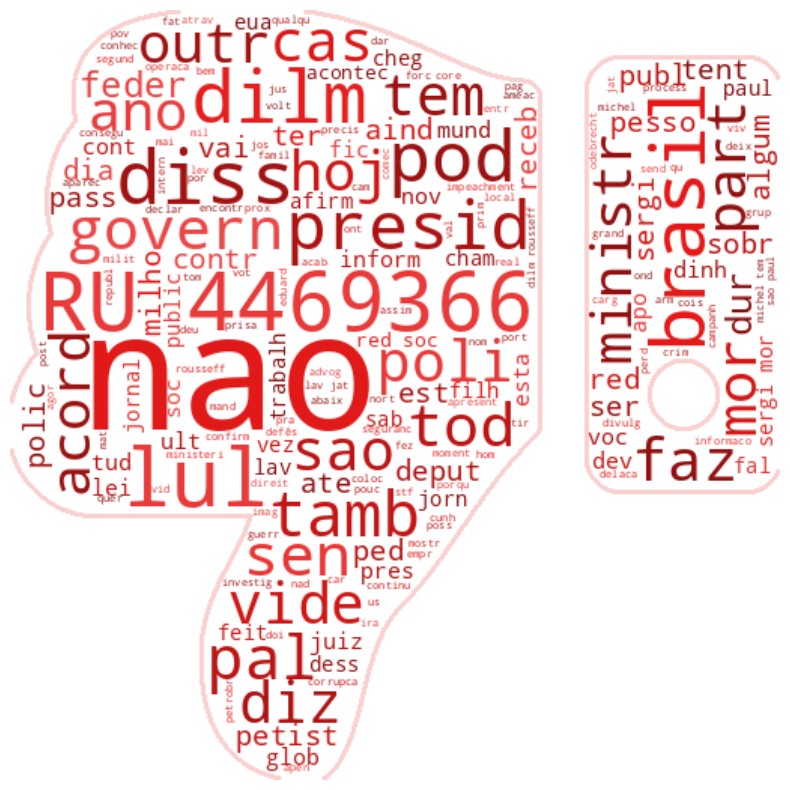

In [60]:
# Conta unigramas e bigramas no dicionário FAKE
total_tokens_fake_RU = len(dict_fake_RU)
unigramas_fake  = sum(1 for k in dict_fake_RU if len(k.split()) == 1 and not k.startswith('RU'))
bigramas_fake   = sum(1 for k in dict_fake_RU if len(k.split()) == 2 and not k.startswith('RU'))
trigramas_fake  = sum(1 for k in dict_fake_RU if len(k.split()) >= 3 and not k.startswith('RU'))

print('=== QUESTÃO 02 — Textos FALSOS (FAKE) ===')
print(f'Unigramas usados : {unigramas_fake}')
print(f'Bigramas usados  : {bigramas_fake}')
print(f'Trigramas usados : {trigramas_fake}')
print(f'Total de tokens  : {total_tokens_fake_RU}')
print(f'Acurácia do modelo: {acuracia_RU * 100:.2f}%')
print(f'RU: {RU}')

# Gera a nuvem de palavras para FAKE (polegar para baixo = vermelho)
print('\nGerando nuvem de palavras FAKE...')
# Corrigido: Passando apenas o nome do arquivo
nuvem_fake, n_tokens_fake = gerar_nuvem_palavras(
    arquivo_mascara='thumbs_down_mask.png',
    dicionario_tokens_e_frequencia=dict_fake_RU
)

### Resposta — Questão 02

**Pergunta:** Quantas palavras, bigramas e trigramas foram usados dos textos rotulados como FAKE para a criação de seu modelo, quais foram as técnicas usadas em seu pré-processamento e qual tipo de modelo foi escolhido para este classificador?

**Resposta:** (Preencher com os valores impressos pela célula acima após executar.)

Exemplo de preenchimento:
- Unigramas: `<valor impresso>`
- Bigramas: `<valor impresso>`
- Trigramas: 0 (ngram_range=(1,2))
- Total de tokens: `<valor impresso>`
- Acurácia: `<valor impresso>`%
- Técnicas: lowercase, remoção de caracteres especiais (regex), tokenização NLTK, remoção de stopwords NLTK (pt), stemming RSLP NLTK, normalização de tamanho dos textos (truncagem), TF-IDF com unigramas e bigramas
- Modelo: Regressão Logística (LogisticRegression, scikit-learn)

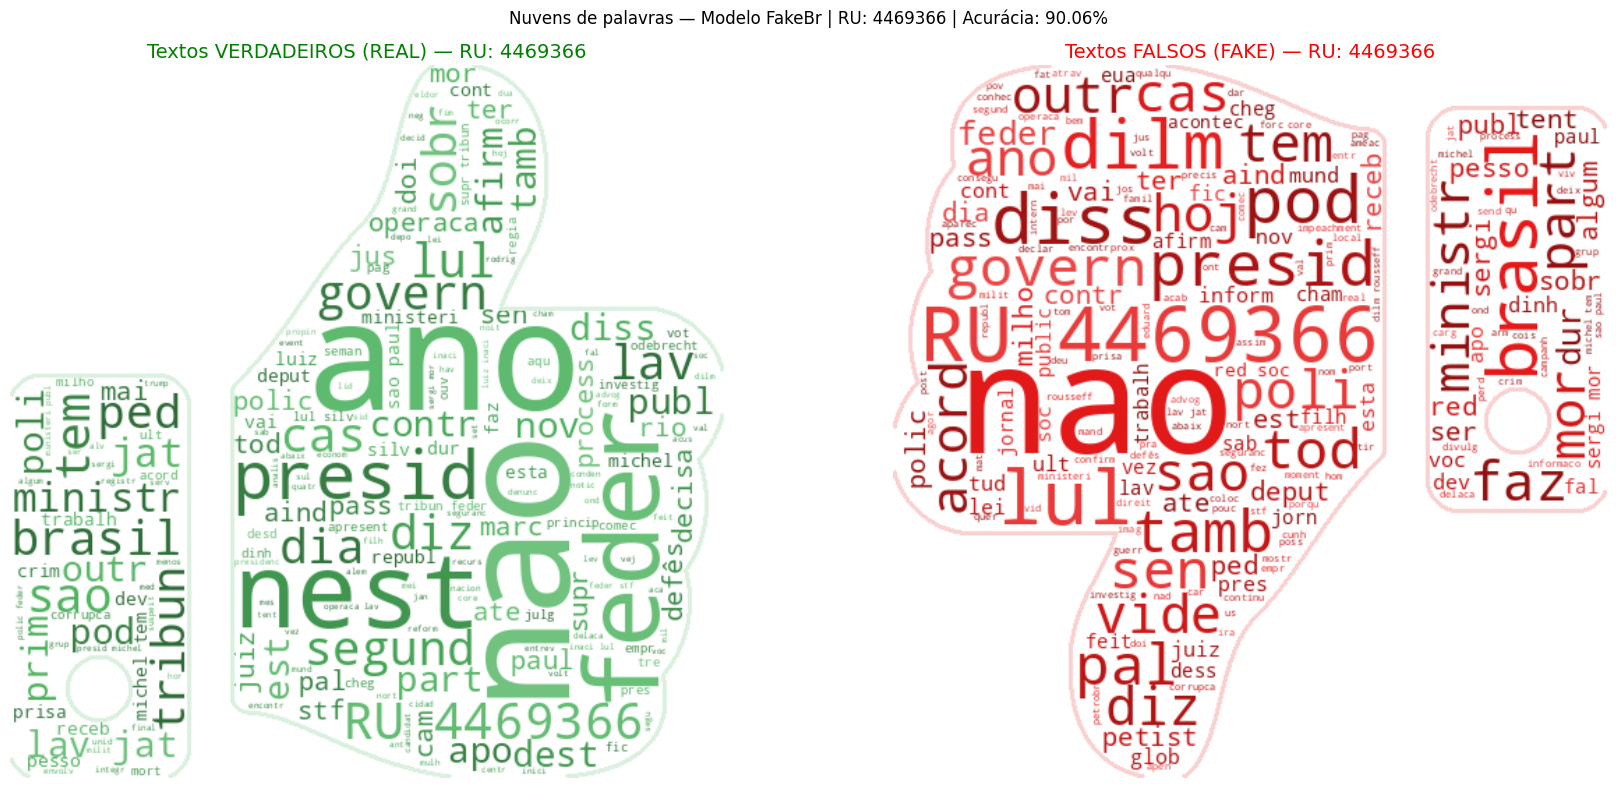

Imagem salva como nuvens_palavras_resultado.png


In [62]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

axes[0].imshow(nuvem_real, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title(f'Textos VERDADEIROS (REAL) — RU: {RU}', fontsize=14, color='green')

axes[1].imshow(nuvem_fake, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title(f'Textos FALSOS (FAKE) — RU: {RU}', fontsize=14, color='red')

plt.suptitle(f'Nuvens de palavras — Modelo FakeBr | RU: {RU} | Acurácia: {acuracia_RU*100:.2f}%',
             fontsize=12)
plt.tight_layout()
plt.savefig('nuvens_palavras_resultado.png', dpi=150, bbox_inches='tight')
plt.show()
print('Imagem salva como nuvens_palavras_resultado.png')